# Задание 1. Геометрия данных в пространстве признаков

In [10]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn
!pip install umap-learn
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 2.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 1.6 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.2 MB 1.6 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 1.9 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 1.9 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 1.6 MB/s  0:00:01

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Online Retail.csv', sep=';')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M', errors='coerce')
df['UnitPrice'] = df['UnitPrice'].str.replace(',', '.').astype(float)
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['InvoiceNo'] = df['InvoiceNo'].astype('category')
df['StockCode'] = df['StockCode'].astype('category')
df['Country'] = df['Country'].astype('category')

Число объектов: 530104
 Число признаков: 21

Число числовых признаков для анализа: 15
Список признаков: ['Quantity', 'UnitPrice', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Description_len', 'Description_words', 'Country_United Kingdom', 'Country_Germany', 'Country_France', 'Country_EIRE', 'Country_Spain', 'Country_Other']


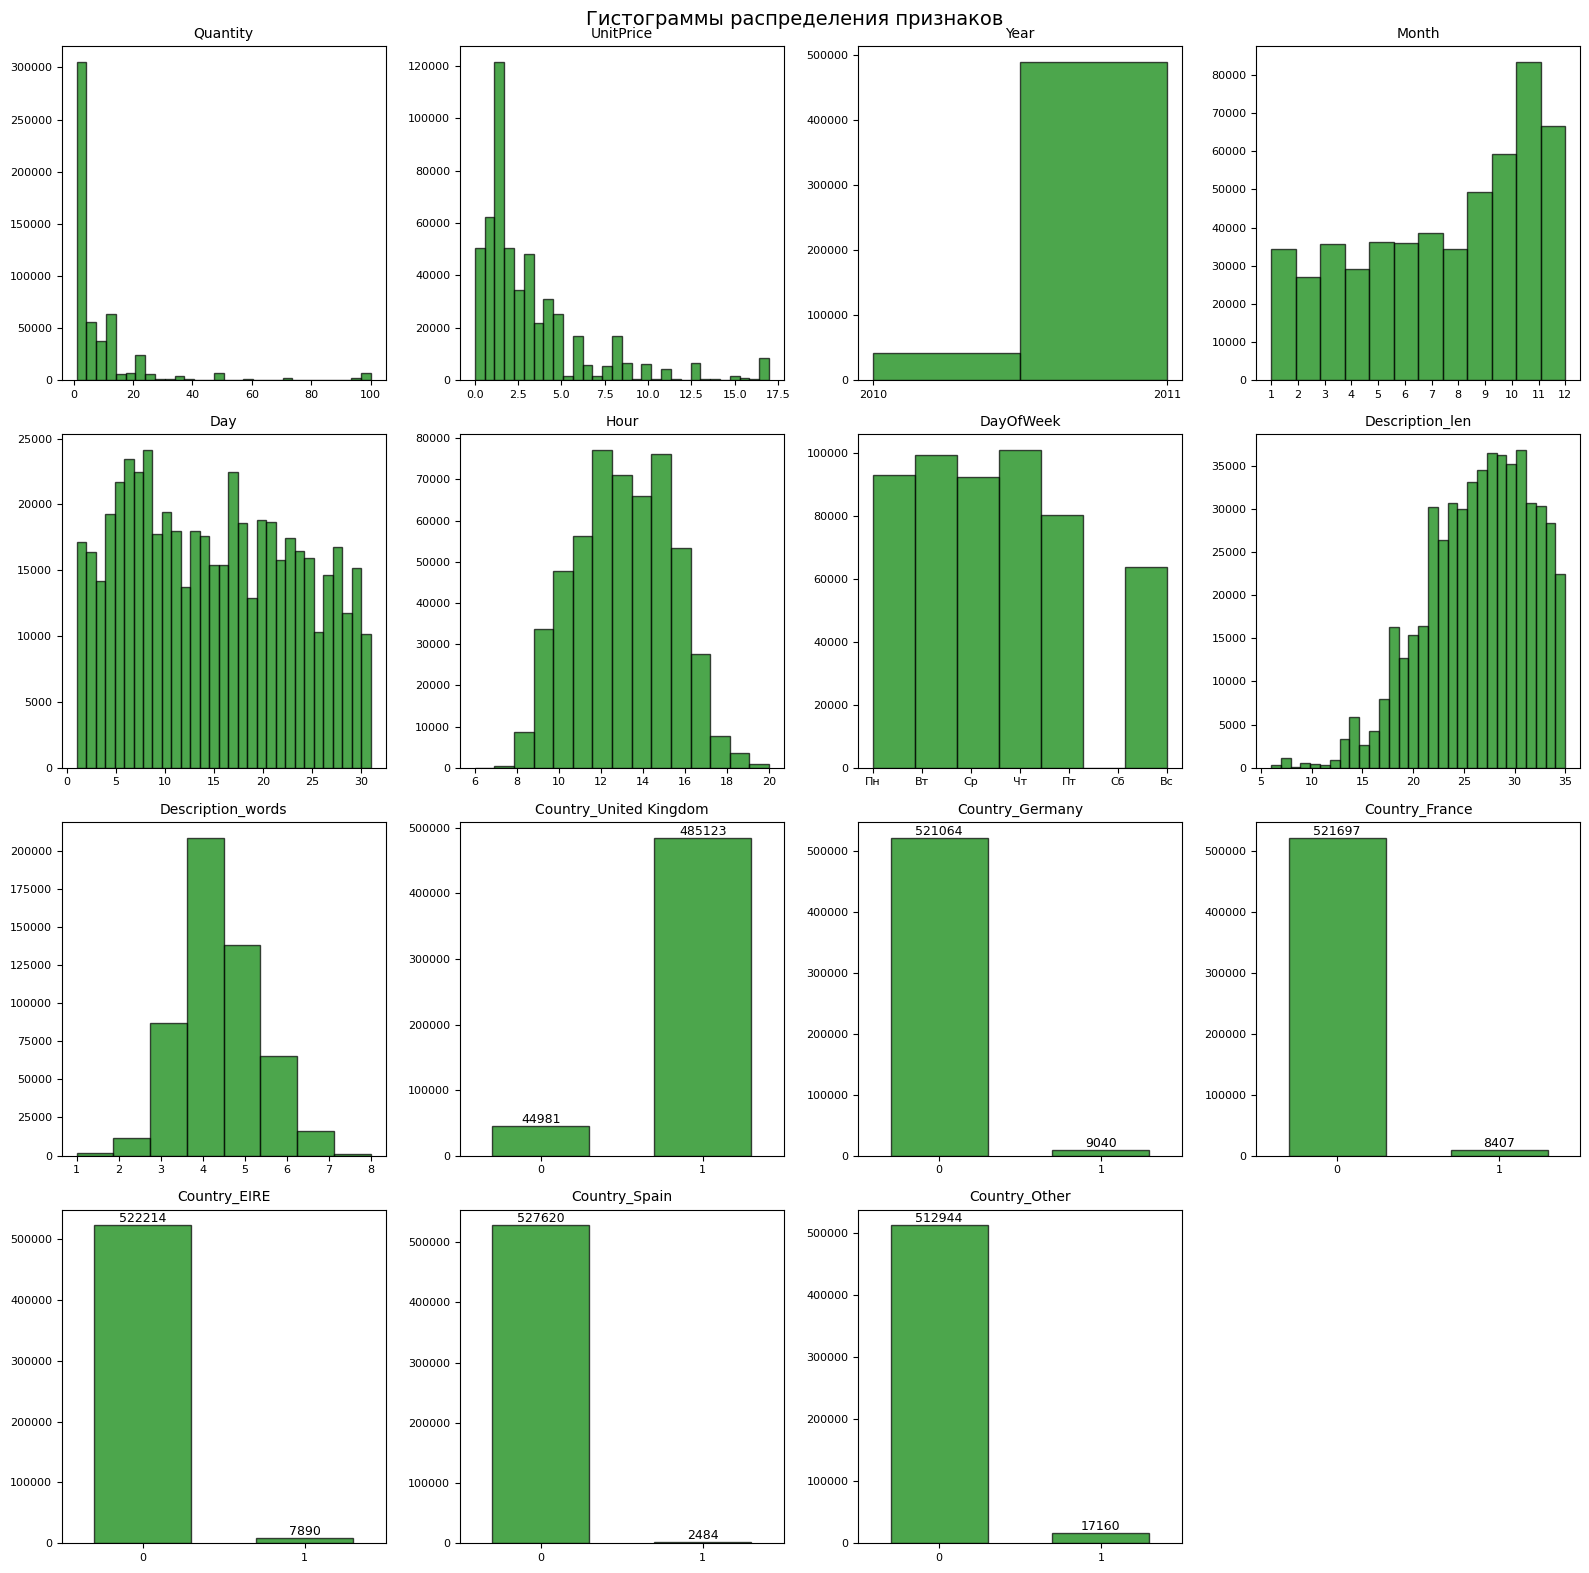

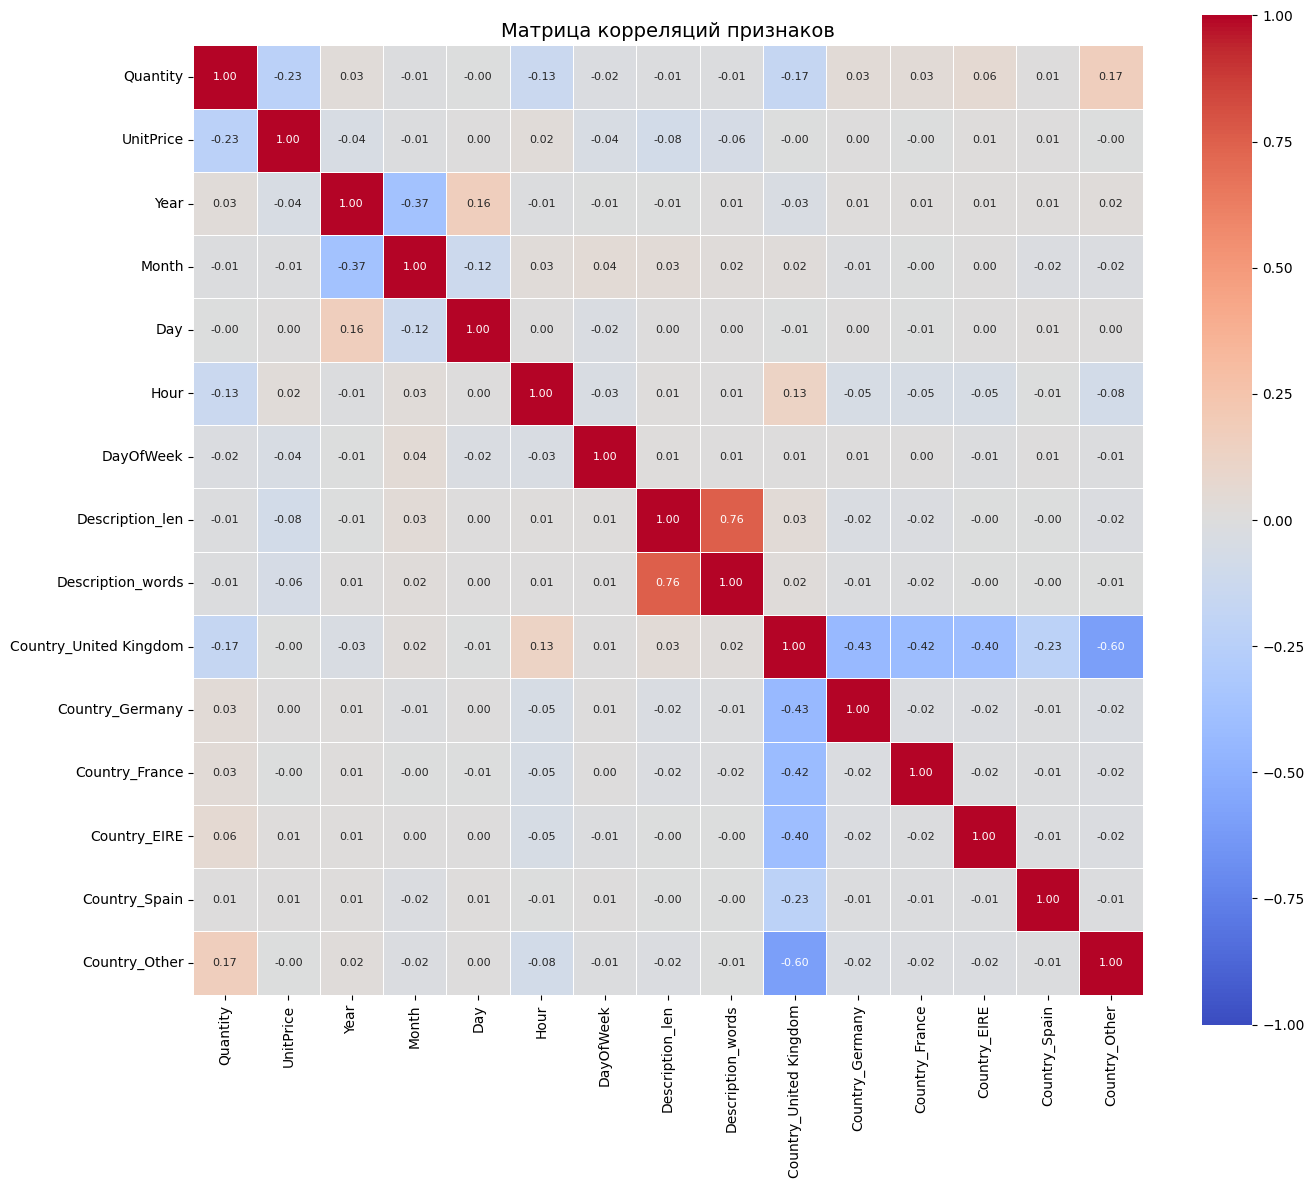

1. Есть ли сильно коррелированные признаки (|r| > 0.7)?
Да, обнаружены:
   - Description_len и Description_words: r = 0.757

2. Можно ли предположить, что часть признаков содержит избыточную информацию?
   Да. Длина описания и количество слов в описании сильно коррелируют (r > 0.7), — чем длиннее текст, тем больше в нём слов. Эти признаки избыточны
   Также наблюдается отрицательная корреляция между некоторыми странами, что естественно для one-hot encoding.

Дополнительные наблюдения по корреляциям:
Большое число предметов в заказе указывает на меньшую цену одной штуки (r = -0.23).
День 5 пуст — компания не работает по субботам.
Год коррелирует с месяцем (r = -0.34) — в 2011 году больше заказов в начале года.
Страны вне топ-5 чаще заказывают больше товаров (r = 0.16 с Quantity).
Более длинные описания соответствуют чуть более дешёвым товарам (r = -0.09).


In [3]:
df = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)]
upper_bound_price = df['UnitPrice'].quantile(0.99)
upper_bound_quantity = df['Quantity'].quantile(0.99)
df['UnitPrice'] = np.where(df['UnitPrice'] > upper_bound_price, upper_bound_price, df['UnitPrice'])
df['Quantity'] = np.where(df['Quantity'] > upper_bound_quantity, upper_bound_quantity, df['Quantity'])

# Создадим числовые признаки из нечисловых
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  # 0=Пн, 6=Вс
df['Description_len'] = df['Description'].fillna('').astype(str).str.len()
df['Description_words'] = df['Description'].fillna('').astype(str).str.split().str.len()
top_countries = df['Country'].value_counts().nlargest(5).index
for country in top_countries:
    df[f'Country_{country}'] = (df['Country'] == country).astype(int)
df['Country_Other'] = (~df['Country'].isin(top_countries)).astype(int)

numeric_cols = [
    # Исходные числовые
    'Quantity', 'UnitPrice',
    # Из даты
    'Year', 'Month', 'Day', 'Hour', 'DayOfWeek',
    # Из строк
    'Description_len', 'Description_words',
    # Из Country
    'Country_United Kingdom', 'Country_Germany', 'Country_France', 
    'Country_EIRE', 'Country_Spain', 'Country_Other'
]
print(f'Число объектов: {df.shape[0]}\n Число признаков: {df.shape[1]}')
print(f'\nЧисло числовых признаков для анализа: {len(numeric_cols)}')
print(f'Список признаков: {numeric_cols}')

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

discrete_cols = ['Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Description_words']
binary_cols = ['Country_United Kingdom', 'Country_Germany', 'Country_France', 
               'Country_EIRE', 'Country_Spain', 'Country_Other', 'IsGuest']

for i, col in enumerate(numeric_cols):
    if col in binary_cols:
        # Для бинарных
        counts = df[col].value_counts().sort_index()
        bars = axes[i].bar(counts.index, counts.values, color='green', 
                          edgecolor='black', alpha=0.7, width=0.6)
        axes[i].set_xticks([0, 1])
        axes[i].set_xlim(-0.5, 1.5)
        for bar, count in zip(bars, counts.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                        str(count), ha='center', va='bottom', fontsize=9)
    elif col in discrete_cols:
        # Для дискретных
        unique_vals = df[col].nunique()
        if col == 'DayOfWeek':
            unique_vals = 7
        counts, bins, patches = axes[i].hist(df[col].dropna(), bins=unique_vals, 
                                             color='green', edgecolor='black', 
                                             alpha=0.7, align='mid')
        if col == 'DayOfWeek':
            axes[i].set_xticks(range(7))
            axes[i].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
        elif col == 'Year':
            axes[i].set_xticks([2010, 2011])
        elif col == 'Month':
            axes[i].set_xticks(range(1, 13))
    else:
        # Для непрерывных - 30 бинов
        axes[i].hist(df[col].dropna(), bins=30, color='green', 
                    edgecolor='black', alpha=0.7)
    
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Убираем пустые subplot'ы
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.suptitle('Гистограммы распределения признаков', fontsize=14)
plt.tight_layout()
plt.show()



corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Матрица корреляций признаков', fontsize=14)
plt.tight_layout()
plt.show()



strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                                corr_matrix.iloc[i, j]))

print('1. Есть ли сильно коррелированные признаки (|r| > 0.7)?')
print('Да, обнаружены:')
for pair in strong_pairs:
    print(f'   - {pair[0]} и {pair[1]}: r = {pair[2]:.3f}')

print('\n2. Можно ли предположить, что часть признаков содержит избыточную информацию?')
if 'Description_len' in [p[0] for p in strong_pairs] and 'Description_words' in [p[1] for p in strong_pairs]:
    print('   Да. Длина описания и количество слов в описании сильно коррелируют (r > 0.7), — чем длиннее текст, тем больше в нём слов. Эти признаки избыточны')
    print('   Также наблюдается отрицательная корреляция между некоторыми странами, что естественно для one-hot encoding.')

print('\nДополнительные наблюдения по корреляциям:')
print('Большое число предметов в заказе указывает на меньшую цену одной штуки (r = -0.23).')
print('День 5 пуст — компания не работает по субботам.')
print('Год коррелирует с месяцем (r = -0.34) — в 2011 году больше заказов в начале года.')
print('Страны вне топ-5 чаще заказывают больше товаров (r = 0.16 с Quantity).')
print('Более длинные описания соответствуют чуть более дешёвым товарам (r = -0.09).')

# Задание 2. Реализация PCA


Сравнение реализаций PCA:
--------------------------------------------------
Компонента   PCA на numpy    Sklearn PCA     Разница        
--------------------------------------------------
1            0.136650        0.136650        1.415534e-15   
2            0.117710        0.117710        1.235123e-15   
3            0.097054        0.097054        3.955170e-15   
4            0.082159        0.082159        8.049117e-16   
5            0.069436        0.069436        7.216450e-16   
Максимальная разница в долях дисперсии: 3.96e-15


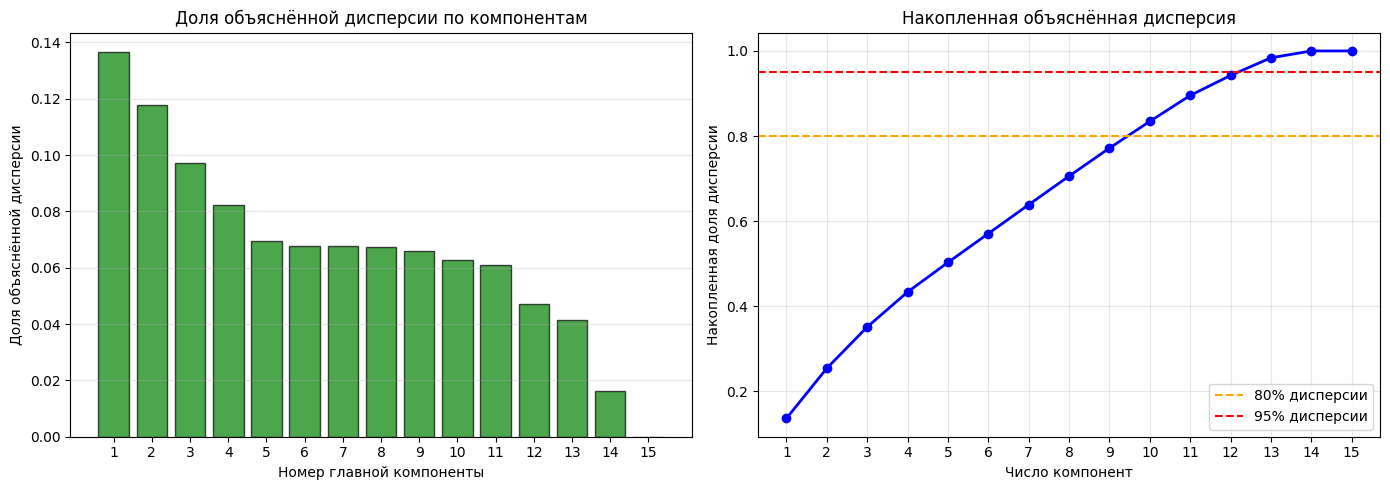

1. 10 компонент объясняют 80% дисперсии
   (накопленная доля: 0.835)
2. 13 компонент объясняют 95% дисперсии
   (накопленная доля: 0.984)

Всего исходных признаков: 15
Первые 3 компоненты объясняют 35.1% дисперсии
Первые 5 компонент объясняют 50.3% дисперсии
Наличие плато (компоненты 5-11 с ~6.5% дисперсии) говорит о том, что признаки содержат много независимых источников вариации.
PCA не даёт сильного снижения размерности, что подтверждает низкую избыточность данных (слабые корреляции между признаками).


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

X = df[numeric_cols].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)   

def pca_from_scratch(X_std, k=None): 
    cov_matrix = np.cov(X_std, rowvar=False)
    
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    if k is not None:
        eigenvectors = eigenvectors[:, :k]
        X_projected = X_std @ eigenvectors
        return X_projected, eigenvalues, eigenvectors
    
    return eigenvalues, eigenvectors

eigenvalues, eigenvectors = pca_from_scratch(X_std)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

sklearn_pca = SklearnPCA()
sklearn_pca.fit(X_std)

print('\nСравнение реализаций PCA:')
print('-' * 50)
print(f'{"Компонента":<12} {"PCA на numpy":<15} {"Sklearn PCA":<15} {"Разница":<15}')
print('-' * 50)
for i in range(min(5, len(eigenvalues))):
    diff = abs(explained_variance_ratio[i] - sklearn_pca.explained_variance_ratio_[i])
    print(f'{i+1:<12} {explained_variance_ratio[i]:<15.6f} {sklearn_pca.explained_variance_ratio_[i]:<15.6f} {diff:<15.6e}')
print(f'Максимальная разница в долях дисперсии: {abs(explained_variance_ratio - sklearn_pca.explained_variance_ratio_).max():.2e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

components = np.arange(1, len(explained_variance_ratio) + 1)
ax1.bar(components, explained_variance_ratio, alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Номер главной компоненты')
ax1.set_ylabel('Доля объяснённой дисперсии')
ax1.set_title('Доля объяснённой дисперсии по компонентам')
ax1.set_xticks(components)
ax1.grid(axis='y', alpha=0.3)

ax2.plot(components, cumulative_variance, 'bo-', markersize=6, linewidth=2)
ax2.axhline(y=0.80, color='orange', linestyle='--', label='80% дисперсии', linewidth=1.5)
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% дисперсии', linewidth=1.5)
ax2.set_xlabel('Число компонент')
ax2.set_ylabel('Накопленная доля дисперсии')
ax2.set_title('Накопленная объяснённая дисперсия')
ax2.set_xticks(components)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f'1. 10 компонент объясняют 80% дисперсии')
print(f'   (накопленная доля: {cumulative_variance[9]:.3f})')

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'2. 13 компонент объясняют 95% дисперсии')
print(f'   (накопленная доля: {cumulative_variance[12]:.3f})')

print(f'\nВсего исходных признаков: {len(numeric_cols)}')
print(f'Первые 3 компоненты объясняют {cumulative_variance[2]:.1%} дисперсии')
print(f'Первые 5 компонент объясняют {cumulative_variance[4]:.1%} дисперсии')

print(f'Наличие плато (компоненты 5-11 с ~6.5% дисперсии) говорит о том, что признаки содержат много независимых источников вариации.')
print(f'PCA не даёт сильного снижения размерности, что подтверждает низкую избыточность данных (слабые корреляции между признаками).')

# Задание 3. Интерпретация главных компонент

In [5]:
loadings = eigenvectors[:, :3]
print('\nКоэффициенты признаков в первых трёх компонентах:')
print(f'\n{"Признак":<25} {"PC1":>10} {"PC2":>10} {"PC3":>10}\n')
for i, col in enumerate(numeric_cols):
    print(f'{col:<25} {loadings[i, 0]:>10.4f} {loadings[i, 1]:>10.4f} {loadings[i, 2]:>10.4f}')

print('\nПризнаки с наибольшим вкладом:\n')

for pc_idx, pc_name in enumerate(['PC1', 'PC2', 'PC3']):
    abs_loadings = np.abs(loadings[:, pc_idx])
    sorted_indices = np.argsort(abs_loadings)[::-1]
    top5_indices = sorted_indices[:5]
    
    print(f'\n{pc_name} (первые 5 признаков):')
    for idx in top5_indices:
        sign = '+' if loadings[idx, pc_idx] > 0 else '-'
        print(f'  {sign} {numeric_cols[idx]:<25} ({loadings[idx, pc_idx]:>7.4f})')

pc1_abs = np.abs(loadings[:, 0])
top_pc1_idx = np.argsort(pc1_abs)[::-1][:3]
print('\n1. На первую компоненту больше всего влияют:')
for idx in top_pc1_idx:
    print(f'   - {numeric_cols[idx]} (коэф: {loadings[idx, 0]:.4f})')

print('\n2. Можно ли интерпретировать первую компоненту?')
print('   Да, компонента имеет явных лидеров по вкладу.')
print('   Это комбинация признаков, связанных со страной заказа.')

print('\n3. Признаки, практически не влияющие на первые три компоненты (|коэф| < 0.1):')
low_influence = []
for i, col in enumerate(numeric_cols):
    if np.all(np.abs(loadings[i, :3]) < 0.1):
        low_influence.append(col)
for col in low_influence:
    print(f'   - {col}')


Коэффициенты признаков в первых трёх компонентах:

Признак                          PC1        PC2        PC3

Quantity                     -0.2465     0.0812     0.0308
UnitPrice                     0.0378    -0.1532    -0.0574
Year                         -0.0772    -0.0010     0.6484
Month                         0.0687     0.0442    -0.6261
Day                          -0.0267    -0.0030     0.3992
Hour                          0.1920    -0.0359    -0.0109
DayOfWeek                     0.0112     0.0207    -0.0798
Description_len               0.1325     0.6861     0.0205
Description_words             0.1199     0.6859     0.0339
Country_United Kingdom        0.6651    -0.1111     0.0855
Country_Germany              -0.2787     0.0298    -0.0430
Country_France               -0.2681     0.0288    -0.0560
Country_EIRE                 -0.2618     0.0583    -0.0477
Country_Spain                -0.1367     0.0229     0.0107
Country_Other                -0.4223     0.0841    -0.0351

Пр

# Задание 4. Визуализация данных

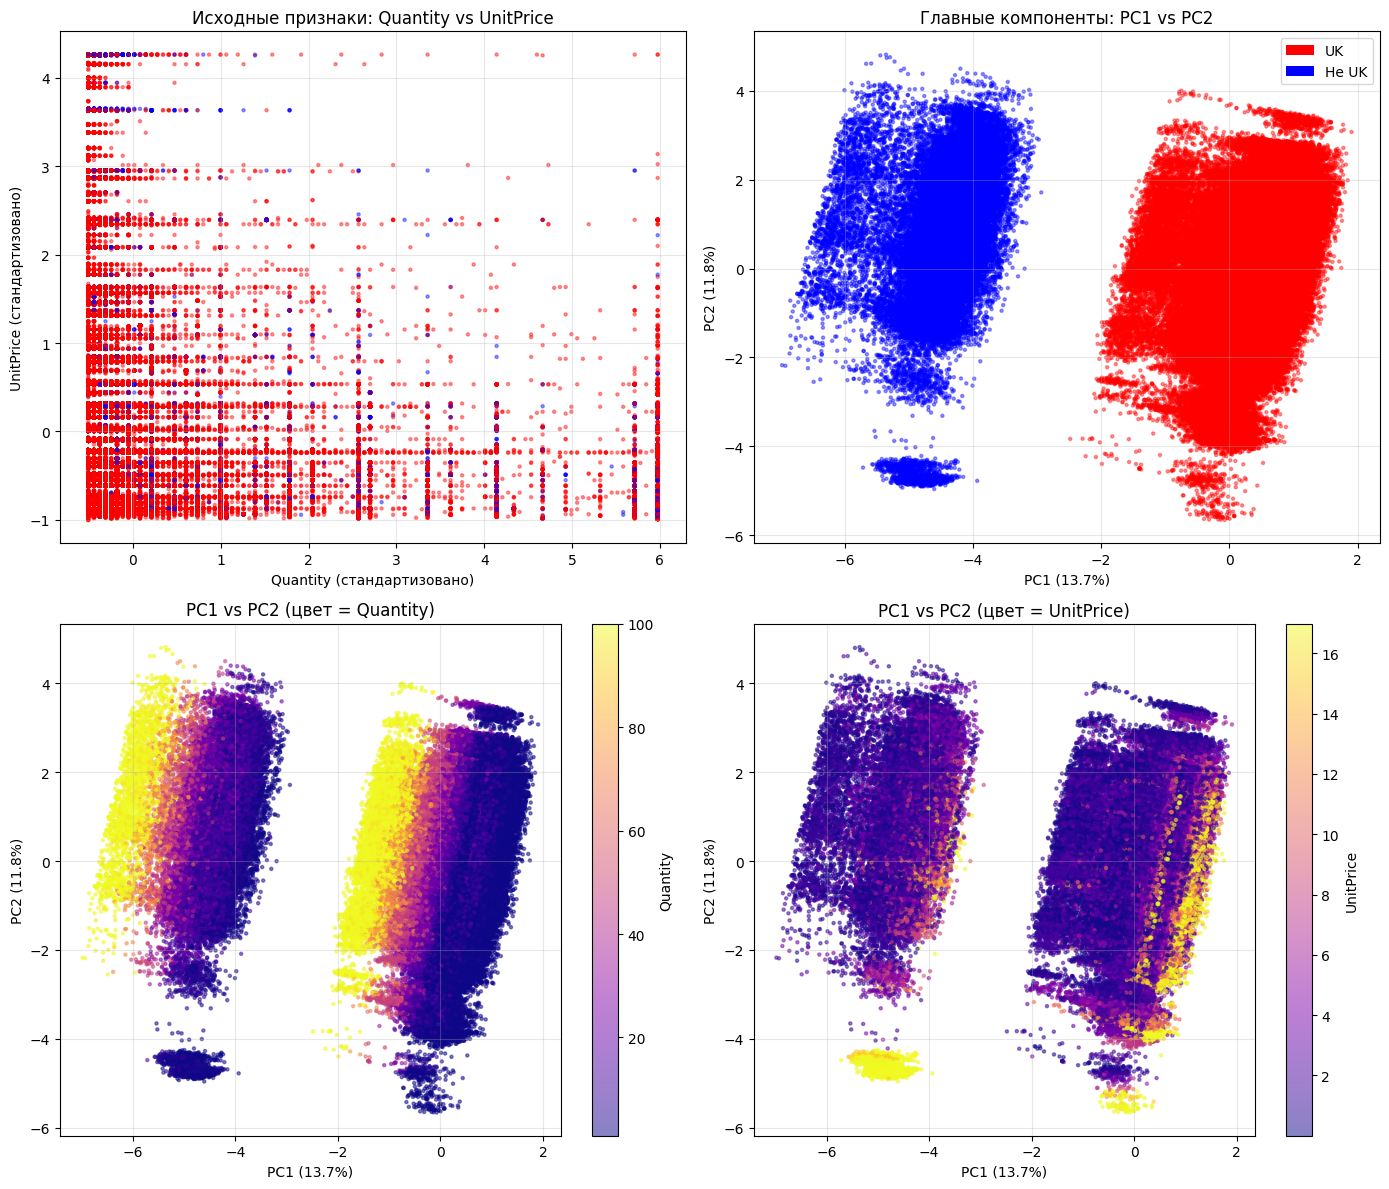


1. Улучшилась ли визуализация после PCA?
Да, хоть разделение на страны в значительной степени усилилось за счет применения one-hot encoding, высокие значения признаков Quantity и UnitPrice также обособились в группы

2. Почему в пространстве главных компонент структура заметнее?
One-hot признаки стран имеют большой вес в компонентах, поэтому разделение UK/не-UK становится явным, в исходной паре этой информации нет.
В то же время высокие значения Quantity и UnitPrice могли обособиться как результат учёта влияния других признаков


In [6]:
X_projected = X_std @ eigenvectors[:, :2]

idx_q = numeric_cols.index('Quantity')
idx_up = numeric_cols.index('UnitPrice')

fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

colors = df['Country_United Kingdom'].map({1: 'red', 0: 'blue'})

ax1.scatter(X_std[:, idx_q], X_std[:, idx_up], c=colors, alpha=0.4, s=5)
ax1.set_xlabel('Quantity (стандартизовано)')
ax1.set_ylabel('UnitPrice (стандартизовано)')
ax1.set_title('Исходные признаки: Quantity vs UnitPrice')
ax1.grid(alpha=0.3)

ax2.scatter(X_projected[:, 0], X_projected[:, 1], c=colors, alpha=0.4, s=5)
ax2.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})')
ax2.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')
ax2.set_title('Главные компоненты: PC1 vs PC2')
ax2.grid(alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='UK'), 
                   Patch(facecolor='blue', label='Не UK')]
ax2.legend(handles=legend_elements)

ax3.scatter(X_projected[:, 0], X_projected[:, 1], 
                      c=df['Quantity'], cmap='plasma', alpha=0.5, s=5)
ax3.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})')
ax3.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')
ax3.set_title('PC1 vs PC2 (цвет = Quantity)')
ax3.grid(alpha=0.3)
plt.colorbar(ax3.collections[0], ax=ax3, label='Quantity')

ax4.scatter(X_projected[:, 0], X_projected[:, 1], 
                      c=df['UnitPrice'], cmap='plasma', alpha=0.5, s=5)
ax4.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})')
ax4.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')
ax4.set_title('PC1 vs PC2 (цвет = UnitPrice)')
ax4.grid(alpha=0.3)
plt.colorbar(ax4.collections[0], ax=ax4, label='UnitPrice')

plt.tight_layout()
plt.show()

print('\n1. Улучшилась ли визуализация после PCA?')
print('Да, хоть разделение на страны в значительной степени усилилось за счет применения one-hot encoding, высокие значения признаков Quantity и UnitPrice также обособились в группы')

print('\n2. Почему в пространстве главных компонент структура заметнее?')
print('One-hot признаки стран имеют большой вес в компонентах, поэтому разделение UK/не-UK становится явным, в исходной паре этой информации нет.')
print('В то же время высокие значения Quantity и UnitPrice могли обособиться как результат учёта влияния других признаков')

# Задание 5. Нелинейные методы снижения размерности

Возьмем подвыборку размером в 5000 элементов


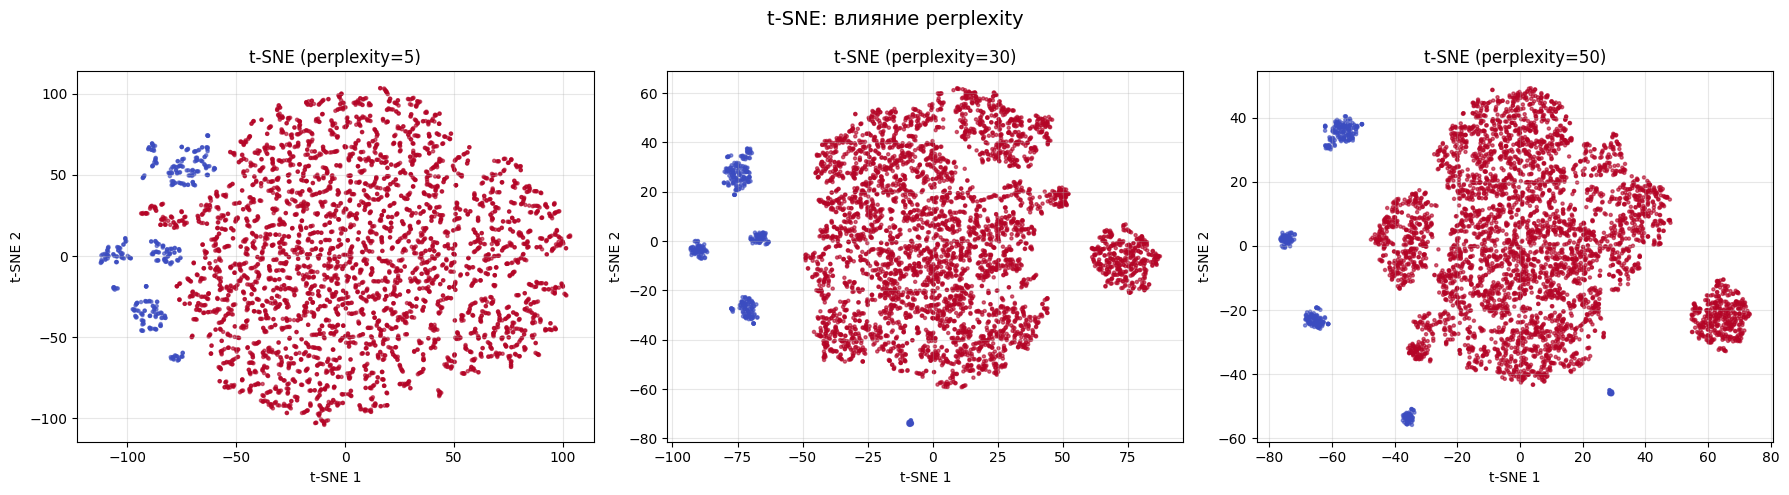

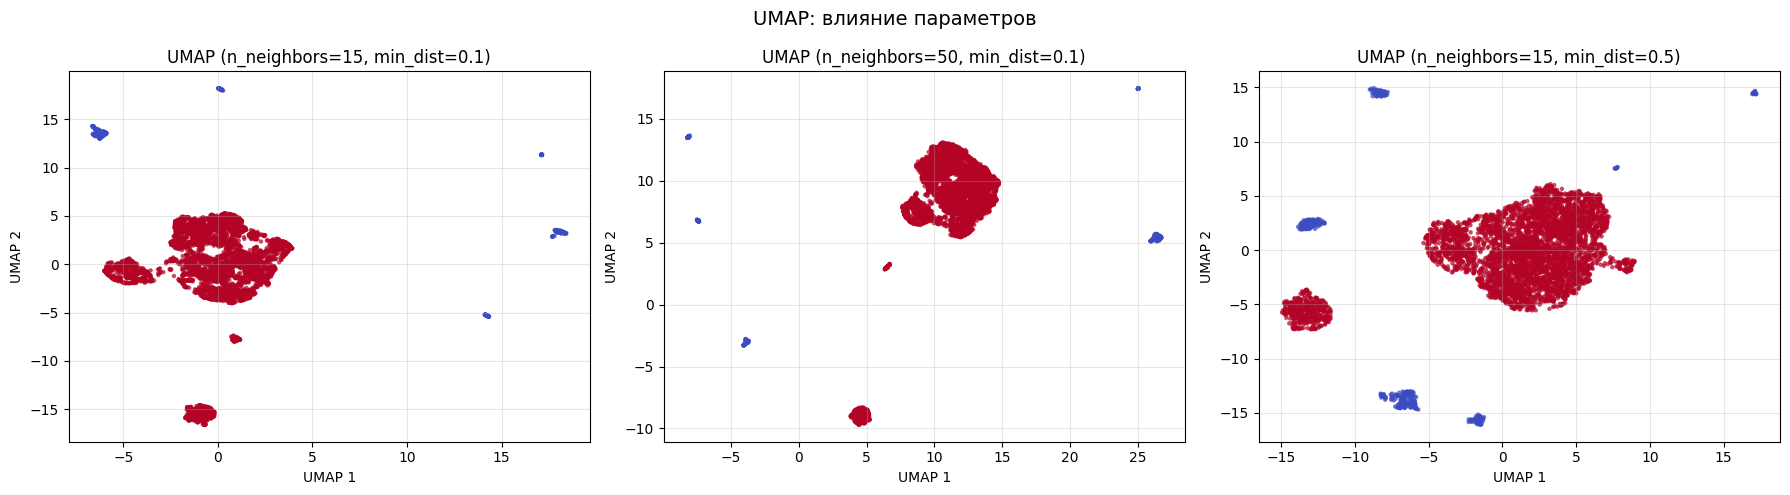

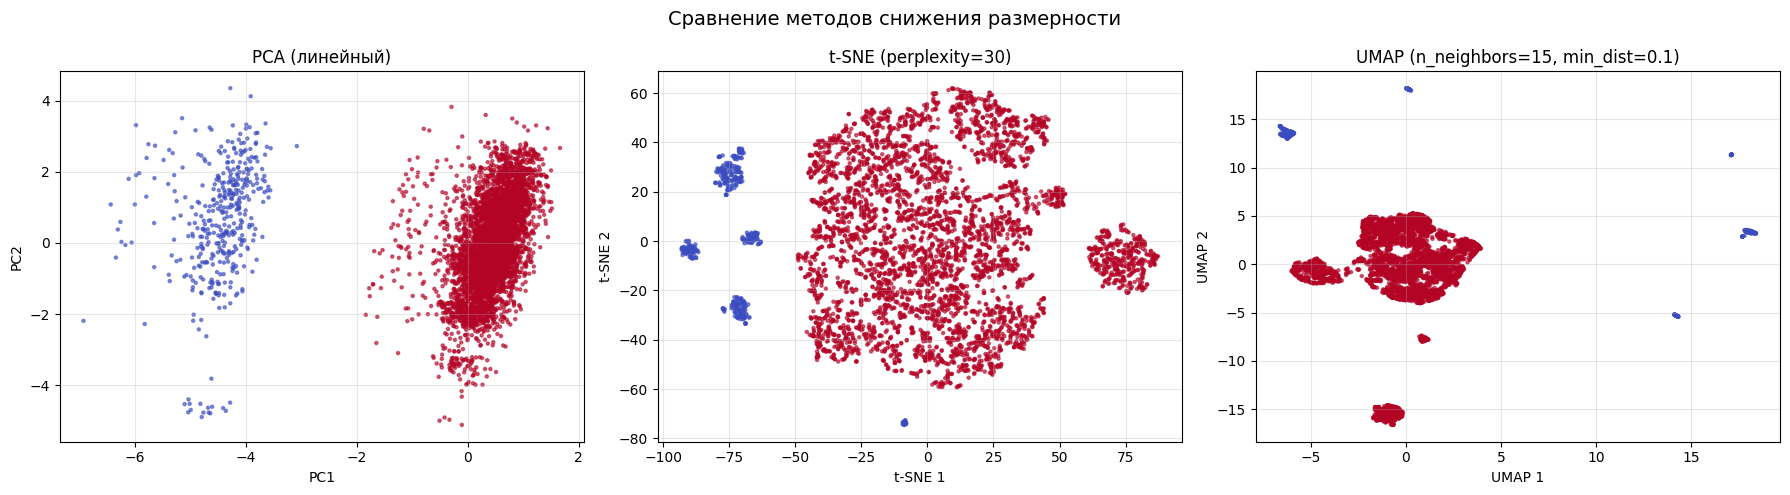


1. Как меняется структура данных при разных параметрах?
   t-SNE: С увеличением параметра perplexity кластеры сжимаются в более плотные
   UMAP:
   - n_neighbors=15: больше локальных деталей, кластеры чётче
   - n_neighbors=50: более глобальная структура, кластеры сливаются
   - min_dist=0.5: точки сильнее разбросаны, кластеры менее плотные

2. Какой метод даёт наиболее интерпретируемую визуализацию?
   UMAP с n_neighbors=15 даёт наиболее чёткую кластерную структуру.
   t-SNE также хорошо разделяет группы, но более чувствителен к шуму.
   PCA даёт самую "гладкую" картину без резких границ между группами.

3. Почему результаты разных методов могут существенно отличаться?
   - PCA: линейный, сохраняет глобальную структуру и расстояния
   - t-SNE: нелинейный, сохраняет локальное соседство, "разрывает" глобальную структуру
   - UMAP: нелинейный, компромисс между локальным и глобальным, быстрее t-SNE
   - Разные целевые функции: PCA максимизирует дисперсию, t-SNE/UMAP — вероятность соседст

In [12]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='umap')
from sklearn.manifold import TSNE
import umap

n_samples = 5000
print(f"Возьмем подвыборку размером в {n_samples} элементов")
np.random.seed(42)
idx_sample = np.random.choice(len(X_std), n_samples, replace=False)
X_sample = X_std[idx_sample]
df_sample = df.iloc[idx_sample]

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_sample)
    
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                    c=df_sample['Country_United Kingdom'], 
                    cmap='coolwarm', alpha=0.6, s=5)
    axes[i].set_title(f't-SNE (perplexity={perp})')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
    axes[i].grid(alpha=0.3)

plt.suptitle('t-SNE: влияние perplexity', fontsize=14)
plt.tight_layout()
plt.show()

umap_params = [
    {'n_neighbors': 15, 'min_dist': 0.1},
    {'n_neighbors': 50, 'min_dist': 0.1},
    {'n_neighbors': 15, 'min_dist': 0.5}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, params in enumerate(umap_params):
    reducer = umap.UMAP(n_components=2, random_state=42, **params)
    X_umap = reducer.fit_transform(X_sample)
    
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], 
                    c=df_sample['Country_United Kingdom'], 
                    cmap='coolwarm', alpha=0.6, s=5)
    axes[i].set_title(f'UMAP (n_neighbors={params["n_neighbors"]}, min_dist={params["min_dist"]})')
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')
    axes[i].grid(alpha=0.3)

plt.suptitle('UMAP: влияние параметров', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_pca_sample = X_sample @ eigenvectors[:, :2]
axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], 
                c=df_sample['Country_United Kingdom'], 
                cmap='coolwarm', alpha=0.6, s=5)
axes[0].set_title('PCA (линейный)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                c=df_sample['Country_United Kingdom'], 
                cmap='coolwarm', alpha=0.6, s=5)
axes[1].set_title('t-SNE (perplexity=30)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(alpha=0.3)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_sample)
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], 
                c=df_sample['Country_United Kingdom'], 
                cmap='coolwarm', alpha=0.6, s=5)
axes[2].set_title('UMAP (n_neighbors=15, min_dist=0.1)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
axes[2].grid(alpha=0.3)

plt.suptitle('Сравнение методов снижения размерности', fontsize=14)
plt.tight_layout()
plt.show()

print('\n1. Как меняется структура данных при разных параметрах?')
print('t-SNE: С увеличением параметра perplexity кластеры сжимаются в более плотные.')
print('UMAP: Увеличение n_neighbors сжало существующие кластеры, увеличение min_dist сделало кластеры менее плотными')

print('\n2. Какой метод даёт наиболее интерпретируемую визуализацию?')
print('UMAP даёт наиболее чёткое разделение кластеров, t-SNE кластеризует данные но позволяет увидеть разделение данных внутри больших кластеров, PCA хуже кластеры но лучше показывает глобальное расположение точек относительно друг друга')

print('\n3. Почему результаты разных методов могут существенно отличаться?')
print('PCA: линейный, сохраняет глобальную структуру и расстояния')
print('t-SNE: нелинейный, сохраняет локальное соседство, "разрывает" глобальную структуру')
print('UMAP: нелинейный, компромисс между локальным и глобальным, быстрее t-SNE')
print('PCA максимизирует дисперсию, t-SNE/UMAP — вероятность соседства')

# Задание 6. Исследование степени сжатия данных

--------------------------------------------------
Число компонент    MSE             Объяснённая дисперсия
--------------------------------------------------
2                  0.745640        0.254               
5                  0.496991        0.503               
10                 0.165463        0.835               
15                 0.000000        1.000               


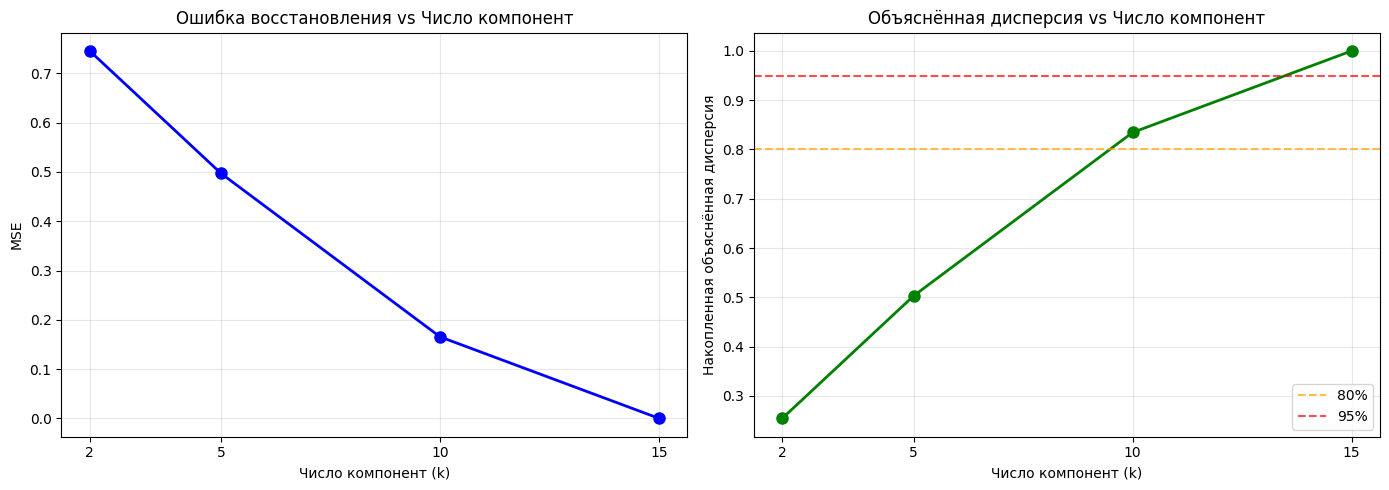


1. Почему при малом числе компонент ошибка восстановления большая?
При k=2 сохраняется только 25% дисперсии, теряется 75% информации.
Восстановление из 2 компонент игнорирует большую часть вариации данных.

2. Почему увеличение числа компонент уменьшает ошибку?
Каждая новая компонента добавляет информацию о данных. Увеличение числа компонент позволяет сохранить большее число дисперсии и сократить ошибку

3. Можно ли полностью восстановить данные при всех компонентах?
Да, при k=15 (все компоненты) MSE = 0.

4. Как это связано с объяснённой дисперсией PCA?
MSE и объяснённая дисперсия связаны: MSE = 1 - накопленная дисперсия.

5. Как определить разумное число компонент?
Найти на графике MSE точку, где кривая выходит на плато, либо взять количество компонент обеспечивающее необходимую объясненную дисперсию.
Например, для имеющихся данных данных разумное k ≈ 10 (Обеспечено >80% дисперсии, MSE ≈ 0.16)


In [14]:
from sklearn.metrics import mean_squared_error
k_values = [2, 5, 10, 15]
mse_results = []

print('-' * 50)
print(f'{"Число компонент":<18} {"MSE":<15} {"Объяснённая дисперсия":<20}')
print('-' * 50)

for k in k_values:
    pca_k = SklearnPCA(n_components=k)
    X_projected_k = pca_k.fit_transform(X_std)
    X_reconstructed = pca_k.inverse_transform(X_projected_k)
    mse = mean_squared_error(X_std, X_reconstructed)
    mse_results.append(mse)
    cum_var = np.sum(explained_variance_ratio[:k])
    
    print(f'{k:<18} {mse:<15.6f} {cum_var:<20.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_values, mse_results, 'bo-', markersize=8, linewidth=2)
ax1.set_xlabel('Число компонент (k)')
ax1.set_ylabel('MSE')
ax1.set_title('Ошибка восстановления vs Число компонент')
ax1.grid(alpha=0.3)
ax1.set_xticks(k_values)

cum_vars = [np.sum(explained_variance_ratio[:k]) for k in k_values]
ax2.plot(k_values, cum_vars, 'go-', markersize=8, linewidth=2)
ax2.set_xlabel('Число компонент (k)')
ax2.set_ylabel('Накопленная объяснённая дисперсия')
ax2.set_title('Объяснённая дисперсия vs Число компонент')
ax2.grid(alpha=0.3)
ax2.set_xticks(k_values)
ax2.axhline(y=0.80, color='orange', linestyle='--', alpha=0.7, label='80%')
ax2.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95%')
ax2.legend()

plt.tight_layout()
plt.show()

print('\n1. Почему при малом числе компонент ошибка восстановления большая?')
print('При k=2 сохраняется только 25% дисперсии, теряется 75% информации.')
print('Восстановление из 2 компонент игнорирует большую часть вариации данных.')

print('\n2. Почему увеличение числа компонент уменьшает ошибку?')
print('Каждая новая компонента добавляет информацию о данных. Увеличение числа компонент позволяет сохранить большее число дисперсии и сократить ошибку')

print('\n3. Можно ли полностью восстановить данные при всех компонентах?')
print('Да, при k=15 (все компоненты) MSE = 0.')

print('\n4. Как это связано с объяснённой дисперсией PCA?')
print('MSE и объяснённая дисперсия связаны: MSE = 1 - накопленная дисперсия.')

print('\n5. Как определить разумное число компонент?')
print('Найти на графике MSE точку, где кривая выходит на плато, либо взять количество компонент обеспечивающее необходимую объясненную дисперсию.')
print('Например, для имеющихся данных данных разумное k ≈ 10 (Обеспечено >80% дисперсии, MSE ≈ 0.16)')

# Задание 7. Итоговый анализ

## 1. Какую роль играет снижение размерности в анализе данных?
Снижение размерности упрощает визуализацию, ускоряет обучение моделей и помогает выявить скрытую структуру данных, отсеивая шум и избыточную информацию.

## 2. Всегда ли уменьшение размерности полезно?
Нет, при сжатии теряется часть информации, что может ухудшить качество моделей, а в некоторых данных просто нет избыточности для эффективного сжатия.

## 3. В каких случаях линейные методы могут работать хуже нелинейных?
Когда данные имеют сложную нелинейную структуру, PCA не сможет её верно отразить.

## 4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?

PCA:  
 Преимущества — быстрый, детерминированный, обратимый, интерпретируемый.  
 Ограничения — не видит нелинейные зависимости, чувствителен к масштабу. 

t-SNE:  
 Преимущества — хорошо выявляет локальные кластеры, удобен для визуализации.  
 Ограничения — медленный, недетерминированный, искажает глобальные расстояния, необратим. 

UMAP:  
 Преимущества — быстрее t-SNE, лучше сохраняет глобальную структуру, чётче разделяет кластеры.  
 Ограничения — результат сильно зависит от параметров, сложнее в интерпретации чем PCA, необратим.